<h1 style="color: skyblue;">Entrenamiento del Bosque Aleatorio con el dataset "Financial Trends and Behavior" <b>Proyecto NN<b></h1>

<hr><hr>

<h3 style="color: cyan;">Integrantes:<h3>
<p>-Antonio Calderón<p>
<h3>-Oriana Ochoa<h3>
<h3>-Gabriela Padilla<h3>
<h3>-Juan Diego Ruales<h3>

<hr><hr>

<p> Este archivo contiene la depuración, transformación del dataset de tendencias de comportamiento financiero. Y a su vez contiene el entrenamiento del random forest con estos datos depurados, para así obtener un archivo .pickle que es el que nos ayudará a poder clasificar el tipo de inversionista en nuestro proyecto <p>

<hr><hr>

In [1]:
#Imports de las librerías a utilizar
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree


In [2]:
#Limpieza y depuración de datos
df=pd.read_csv("D:\\DocumentosI\\EDUCATIVA+\\4to Semestre\\ProyectoNeoNet\\EntrenamientoBosque\\data\\Finance_Trends.csv")
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.head()

,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,...,Duration,Invest_Monitor,Expect,Avenue,What are your savings objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source
0,Male,29,Yes,2,4,7,5,3,1,6,...,Less than 1 year,Weekly,20%-30%,Public Provident Fund,Health Care,Dividend,Fund Diversification,Assured Returns,Fixed Returns,Newspapers and Magazines
1,Male,28,Yes,2,3,6,5,1,4,7,...,Less than 1 year,Weekly,30%-40%,Public Provident Fund,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Risk Free,Television
2,Female,28,Yes,2,3,7,5,4,1,6,...,3-5 years,Daily,10%-20%,Mutual Fund,Health Care,Dividend,Better Returns,Assured Returns,Risk Free,Financial Consultants
3,Male,19,Yes,2,3,7,4,6,1,5,...,More than 5 years,Monthly,10%-20%,Equity,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Risk Free,Newspapers and Magazines
4,Male,32,Yes,2,4,7,5,3,1,6,...,More than 5 years,Weekly,10%-20%,Public Provident Fund,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Fixed Returns,Financial Consultants


In [3]:
#Agrupamos las columnas que tienen menor volatilidad y las de mayor volatilidad en riesgo y seguro para crear nuevas características
df["Score_Riesgo"] = df[["Equity_Market", "Mutual_Funds"]].mean(axis=1)
df["Score_Seguro"] = df[["Fixed_Deposits", "Government_Bonds", "PPF"]].mean(axis=1)

<h2>Modelo XGBOOST (Varios árboles de decisión con algoritmo de gradiente)<h2>

In [4]:
#Función que evalua si el score de riesgo es mayor al score de seguro y asigna un perfil de inversor basado en la diferencia
def definir_perfil(row):
    diferencia = row["Score_Seguro"] - row["Score_Riesgo"]
    if diferencia > 0.5: 
        return "Arriesgado"
    elif diferencia < -0.5: 
        return "Conservador"
    else: 
        return "Moderado"

df["Perfil_Inversor"] = df.apply(definir_perfil, axis=1)

#Vemos cuantas filas hay de cada perfil de inversor
min_count = df["Perfil_Inversor"].value_counts().min()

#Creamos un nuevo df balanceado tomando min_count de cada perfil de inversor
df_balanced = pd.concat([
    df[df["Perfil_Inversor"] == cat].sample(n=min_count, random_state=42)
    for cat in df["Perfil_Inversor"].unique()
])

#División de los datos basado en características (Vamos a clasificar según la columna "Avenue")
features = ["gender", "age", "Factor", "Objective", "Purpose", "Duration", "Expect"]

#Creamos las variaboes dummy para las variables categóricas y codificamos la variable objetivo
X = pd.get_dummies(df_balanced[features], drop_first=True)
le = LabelEncoder()
y = le.fit_transform(df_balanced["Perfil_Inversor"])

#División de los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Creamos el modelo y le entrenamos
xgb_model = XGBClassifier(max_depth=4, n_estimators=200, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

#Hacemos predicciones y evaluamos el modelo
y_pred = xgb_model.predict(X_test)
print("\n=== RESULTADOS XGBOOST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


=== RESULTADOS XGBOOST ===
Accuracy: 0.66

              precision    recall  f1-score   support

  Arriesgado       0.74      0.62      0.67       459
 Conservador       0.57      0.80      0.66       444
    Moderado       0.74      0.57      0.64       475

    accuracy                           0.66      1378
   macro avg       0.68      0.66      0.66      1378
weighted avg       0.68      0.66      0.66      1378



<h2>Modelo RANDOM FOREST (Varios árboles de decisión y votación entre ellos)<h2>

In [5]:
#Entrenamiento del modelo Random Forest
rf_model = RandomForestClassifier(max_depth=4, n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#Hacemos predicciones y evaluamos el modelo Random Forest
y_pred = rf_model.predict(X_test)

print("=== RESULTADOS RANDOM FOREST  ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print(classification_report(y_test, y_pred))

=== RESULTADOS RANDOM FOREST  ===
Accuracy: 0.58

              precision    recall  f1-score   support

           0       0.49      0.73      0.58       459
           1       0.61      0.53      0.57       444
           2       0.76      0.49      0.59       475

    accuracy                           0.58      1378
   macro avg       0.62      0.58      0.58      1378
weighted avg       0.62      0.58      0.58      1378



<h2>Modelo ÁRBOL DE DECISIÓN (Árbol de decisión normal)<h2>

In [6]:
#Entrenamiento del modelo Decision Tree
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

#Hacemos predicciones y evaluamos el modelo Decision Tree
y_pred = clf.predict(X_test)

print("=== RESULTADOS DECISION TREE ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print(classification_report(y_test, y_pred))

=== RESULTADOS DECISION TREE ===
Accuracy: 0.53

              precision    recall  f1-score   support

           0       0.44      0.74      0.55       459
           1       0.58      0.35      0.43       444
           2       0.70      0.49      0.58       475

    accuracy                           0.53      1378
   macro avg       0.57      0.53      0.52      1378
weighted avg       0.57      0.53      0.52      1378



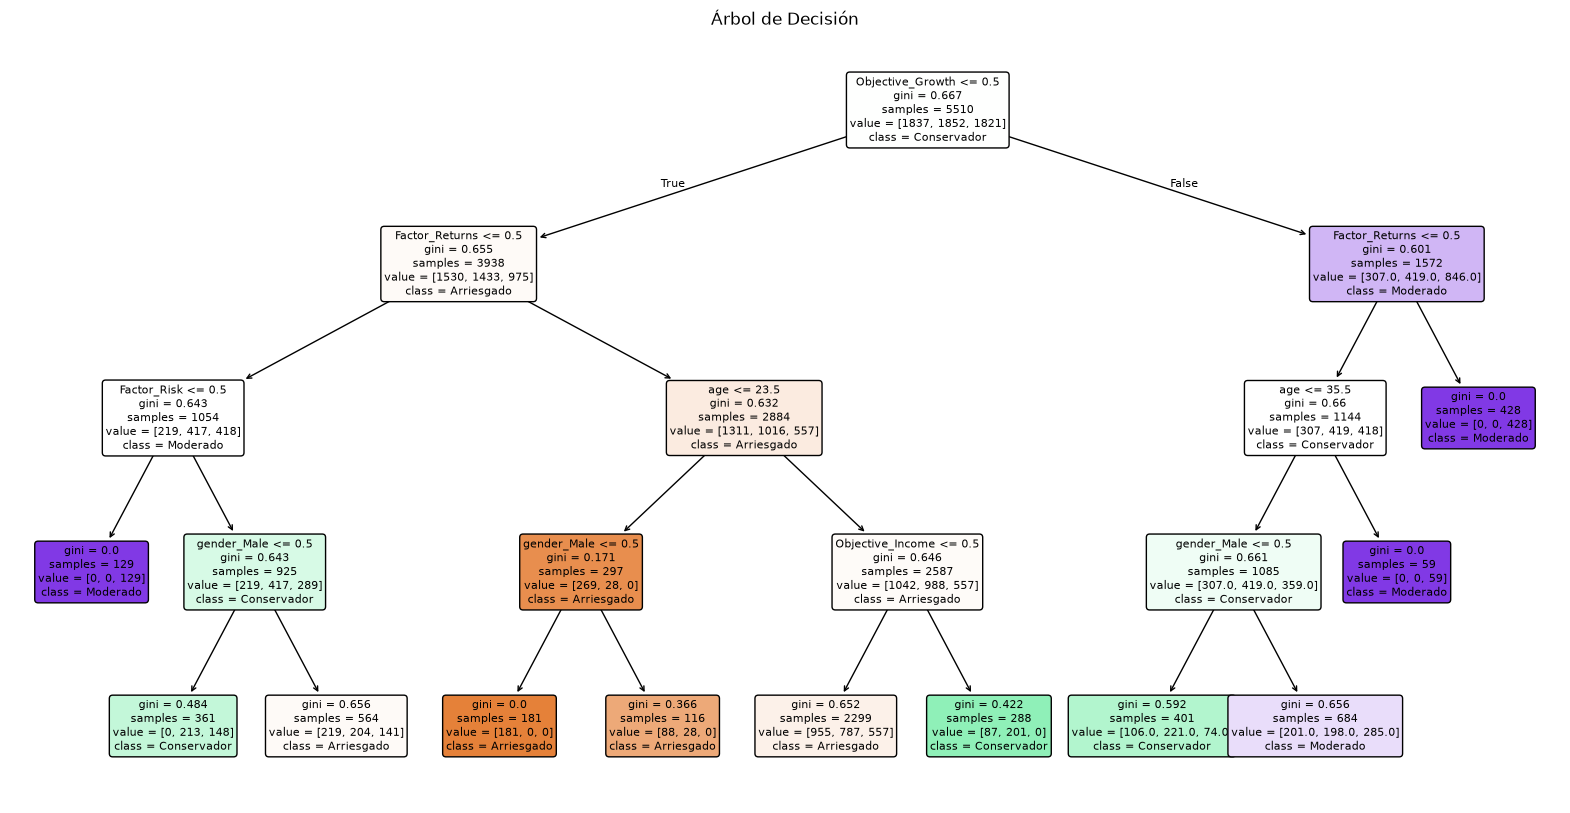

In [7]:

#Visualización del árbol de decisión
plt.figure(figsize=(20,10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Árbol de Decisión")
plt.show()

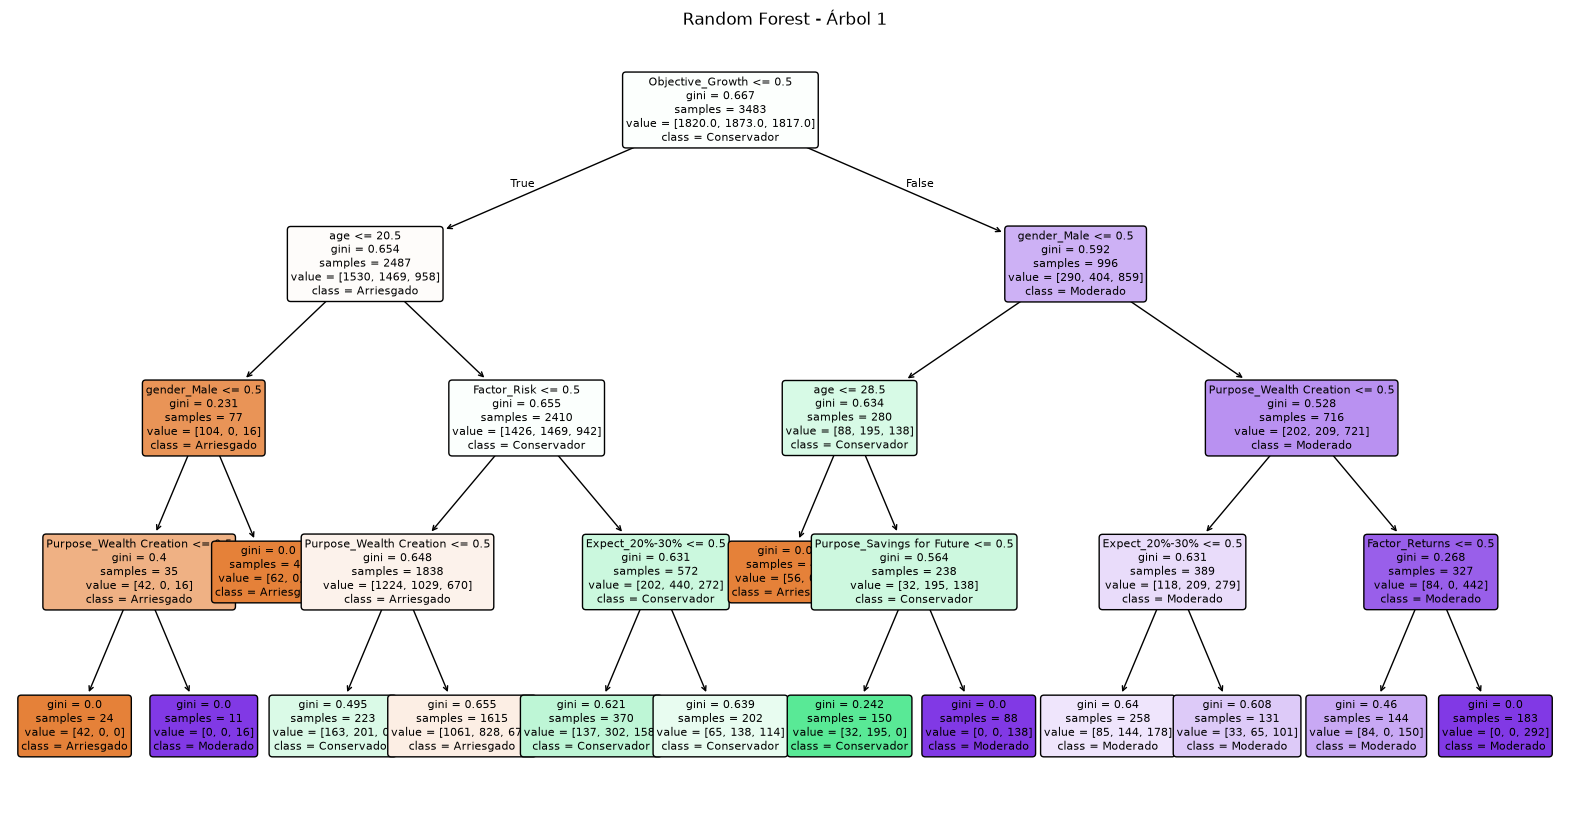

In [8]:
#Visual del arbol de decisión del modelo Random Forest (solo el primer árbol)
rf_model.estimators_
plt.figure(figsize=(20,10))
plot_tree(
    rf_model.estimators_[0],
    feature_names=X.columns,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Random Forest - Árbol 1")
plt.show()

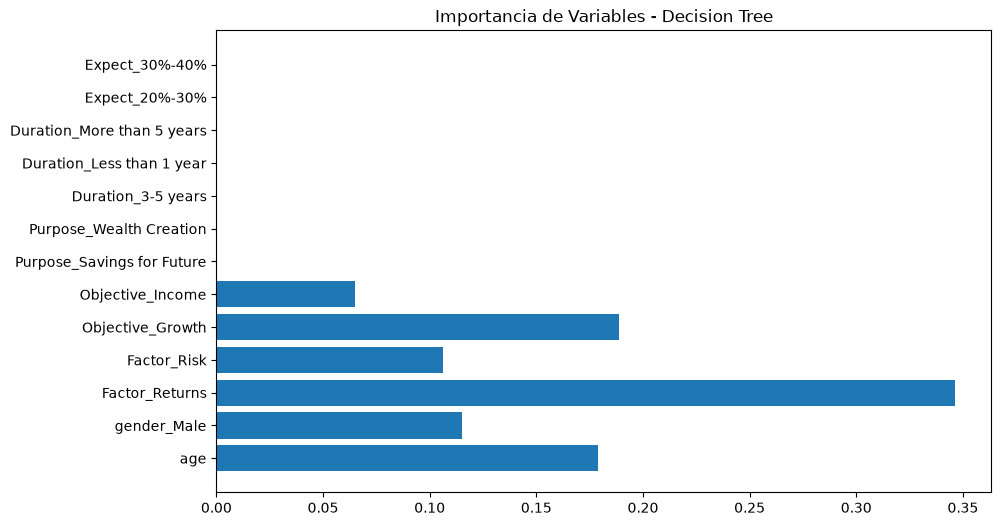

In [9]:
#Grafico de que variables son mas representativas o tuvieron mas peso en el modelo Decision Tree
plt.figure(figsize=(10,6))
plt.barh(X.columns, clf.feature_importances_)
plt.title("Importancia de Variables - Decision Tree")
plt.show()

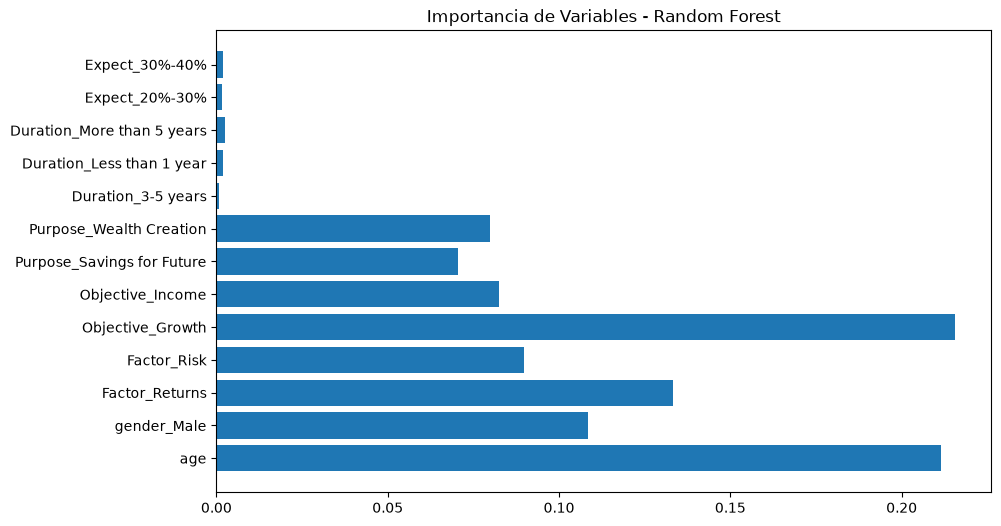

In [10]:
#Grafico de que tan importante son las variables para el modelo Random Forest
plt.figure(figsize=(10,6))
plt.barh(X.columns, rf_model.feature_importances_)
plt.title("Importancia de Variables - Random Forest")
plt.show()

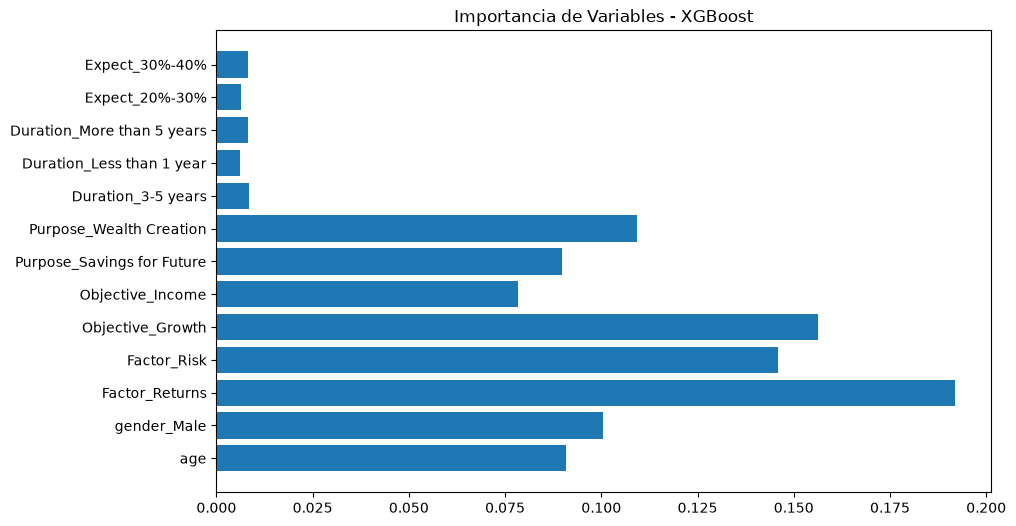

In [11]:
#Grafico de importancia de variables para el modelo XGBoost
plt.figure(figsize=(10,6))
plt.barh(X.columns, xgb_model.feature_importances_)
plt.title("Importancia de Variables - XGBoost")
plt.show()

In [ ]:
import pickle

#Código para guardar el modelo y los artefactos necesarios para hacer predicciones en el futuro
artefactos_modelo = {
    'modelo': xgb_model,
    'label_encoder': le,
    'columnas': X_train.columns
}

with open('modelo_xgboost.pickle', 'wb') as f:
    pickle.dump(artefactos_modelo, f)
    
print("Hecho")

Hecho
